In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv("cleaned_data.csv")
df.head()

,experience_id,imported_class_year,imported_program,imported_unit,major_department,major_unit,notes,person_id,record_id,registrar_class_year,...,participant_programs_unique,participant_record_id_unique,uniqname,registrar_department.1,registrar_program,registrar_type,registrar_unit.1,term_season,year,student_name
0,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance BFA,689.0,abniemi,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi
1,182.0,Sophomore,Dance BFA,NaN,Dance,"Music, Theatre & Dance",Credit Hours: 1,415.0,689.0,Sophomore,...,Dance BFA Dance BFA,14905.0,abniemi,Dance,Dance BFA,Major,"Music, Theatre & Dance",FA,2019,Abby Niemi
2,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA,690.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow
3,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA,2666.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow
4,178.0,Sophomore,Theatre BTA,NaN,Theatre & Drama,"Music, Theatre & Dance",Credit Hours: 1,416.0,690.0,Sophomore,...,Theatre BTA Minor -Playwriting BTA,9947.0,acurnow,Theatre & Drama,Theatre BTA,Major,"Music, Theatre & Dance",FA,2019,Alix Curnow


In [3]:
# There is a lot of majors here. Group similar majors and visualize only the important ones!
counts = df["participant_major_department_unique"].value_counts()
filtered = counts[counts > 1000]

print(len(filtered))
print(filtered)

27
participant_major_department_unique
Composition                                              18501
Winds & Percussion                                       18088
Strings                                                  15512
Piano                                                    12719
Theatre & Drama                                          10394
Voice                                                     5904
Dance                                                     5883
Chamber MusicWinds & Percussion                          3569
Performing Arts Technology                                3332
Theatre & DramaTheatre & Drama                           3316
DanceTheatre & DramaEntrepreneurship & Leadership       2719
Jazz                                                      2685
Conducting                                                2387
Music, Theatre & Dance                                    2187
Winds & PercussionMusic, Theatre & Dance                 2157
Theatre & Drama

In [4]:
engaged_students = df.groupby("student_name").size().reset_index(name="num_experiences")
engaged_students["engaged"] = engaged_students["num_experiences"] >= 1
print(engaged_students)

           student_name  num_experiences  engaged
0              AJ Banta                6     True
1         Aaliyah Brown                9     True
2        Aamiah Griffin                1     True
3         Aaron Ballmer                2     True
4          Aaron Barber                1     True
...                 ...              ...      ...
4775     Zola Hightower               56     True
4776    Zoltan Berencsi                4     True
4777          Zongxi Li               42     True
4778  Zulfiya Bashirova                1     True
4779        Zuri Clarno                4     True

[4780 rows x 3 columns]


In [6]:
student_info = df[["student_name", "major_department", "imported_class_year", "year"]].drop_duplicates()
students = engaged_students.merge(student_info, on="student_name")
print(students)

            student_name  num_experiences  engaged  \
0               AJ Banta                6     True   
1               AJ Banta                6     True   
2          Aaliyah Brown                9     True   
3          Aaliyah Brown                9     True   
4          Aaliyah Brown                9     True   
...                  ...              ...      ...   
10669          Zongxi Li               42     True   
10670          Zongxi Li               42     True   
10671  Zulfiya Bashirova                1     True   
10672        Zuri Clarno                4     True   
10673        Zuri Clarno                4     True   

                                        major_department imported_class_year  \
0                                             Musicology             Masters   
1                                             Musicology              Alumni   
2                                                  Dance           Sophomore   
3                              

In [8]:
grouped = students.groupby(["year", "major_department", "imported_class_year"]).agg(
    engaged_students=("engaged", "sum"),
    total_engaged_records=("student_name", "count")
).reset_index()
print(grouped)

      year                                   major_department  \
0     2015                                       Architecture   
1     2015                                            Biology   
2     2015                                Chamber MusicPiano   
3     2015                   Chamber MusicWinds & Percussion   
4     2015                                        Composition   
...    ...                                                ...   
3775  2025  Winds & PercussionMusic, Theatre & DanceClim...   
3776  2025              Winds & PercussionWinds & Percussion   
3777  2025              Winds & PercussionWinds & Percussion   
3778  2025                         Women's and Gender Studies   
3779  2025                         Women's and Gender Studies   

     imported_class_year  engaged_students  total_engaged_records  
0              Sophomore                 1                      1  
1              Sophomore                 1                      1  
2              

In [14]:
major_counts = df.groupby("major_department")["student_name"].nunique().reset_index()
major_counts.columns = ["major_department", "engaged_students"]

total_engaged = major_counts["engaged_students"].sum()

major_counts["relative_engagement"] = major_counts["engaged_students"] / total_engaged
print(major_counts)

                                      major_department  engaged_students  \
0                                    Academic Outreach                 2   
1                                Aerospace Engineering                 5   
2                               Aerospace Engineering                  2   
3        Aerospace Engineering Music, Theatre & Dance                 1   
4                            AfroAmerican & African St                 1   
..                                                 ...               ...   
850                         Women's and Gender Studies                 2   
851               World Performance StudiesConducting                 1   
852  World Performance StudiesConductingLiteratur...                 1   
853                    World Performance StudiesDance                 3   
854       World Performance StudiesWinds & Percussion                 1   

     relative_engagement  
0               0.000322  
1               0.000804  
2     

In [13]:
df.groupby(["major_department", "imported_class_year"])["student_name"].nunique()

major_department                              imported_class_year
Academic Outreach                             Junior                 1
                                              Senior                 1
Aerospace Engineering                         Junior                 3
                                              Senior                 2
Aerospace Engineering                         Alumni                 1
                                                                    ..
World Performance Studies
Dance               Alumni                 2
                                              Grad Mastr             1
                                              Masters                3
World Performance Studies
Winds & Percussion  Doctorate              1
                                              Masters                1
Name: student_name, Length: 1920, dtype: int64

In [33]:
# -- Clean major_department (keep only the first major if multiple are listed) --
acceptable_majors = {
    "Winds & Percussion",
    "Theatre & Drama",
    "Strings",
    "Composition",
    "Voice",
    "Piano",
    "Dance",
    "Performing Arts Technology",
    "Musical Theatre",
    "Jazz",
    "Conducting",
    "Music, Theatre & Dance",
    "Ross School of Business",
    "Chamber Music",
    "LSA",
    "Music Education",
    "Computer Science",
    "Information",
    "Stamps School of Art & Design",
    "Economics",
    "Communication and Media",
    "Psychology",
    "Musicology",
    "Film, Television, and Media",
    "Biopsych, Cognit & Neurosci",
    "Mechanical Engineering",
    "Political Science",
    "Music",
    "Entrepreneurship & Leadership",
    "Education",
    "Organ"
}

def extract_first_major(entry):
    if pd.isna(entry):
        return entry
    sorted_majors = sorted(acceptable_majors, key=len, reverse=True)
    remaining = entry
    while remaining:
        for major in sorted_majors:
            if remaining.startswith(major):
                return major
        # No match found at start, skip one character and try again
        remaining = remaining[1:]
    return entry  # leave unchanged if no match found

df["major_department"] = df["major_department"].apply(extract_first_major)

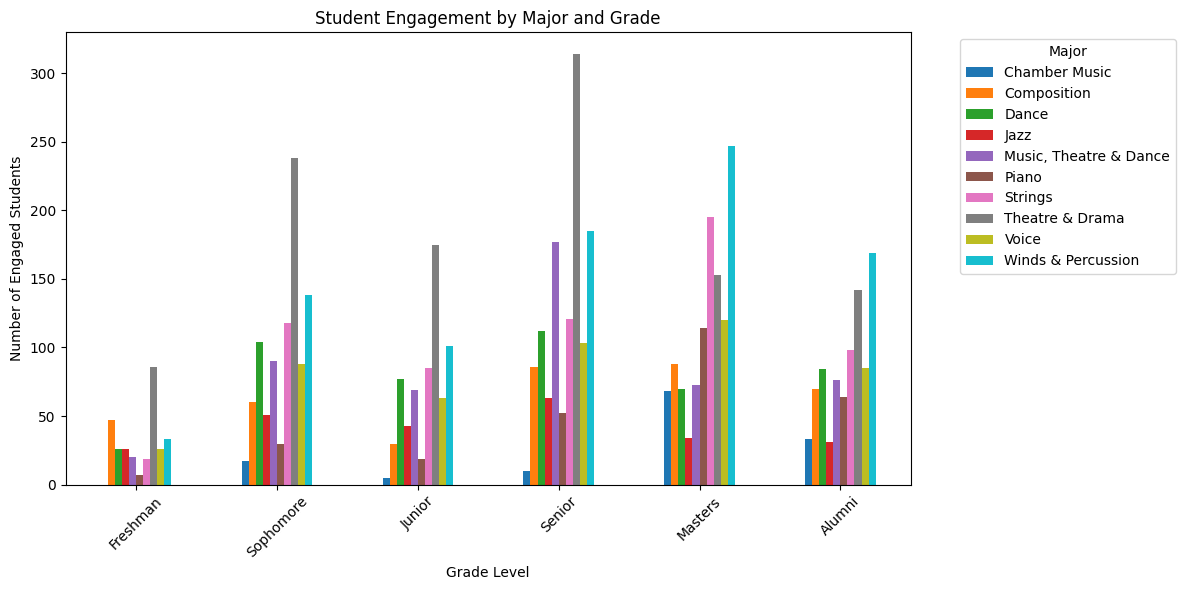

In [36]:
# Rebuild the engagement plot using cleaned major_department values
engagement_by_major_grade = df.groupby(["major_department", "imported_class_year"])["student_name"].nunique().reset_index()
engagement_by_major_grade.columns = ["major_department", "grade", "num_engaged_students"]

# Filter out unwanted grade levels and normalize the master label
unwanted_grades = ["G Pre-Cand", "Grad Cand", "Grad Cert", "Grad Inter", "School Year", "USpec/NCFD", "Pro 2nd YR", "Doctorate"]
engagement_by_major_grade = engagement_by_major_grade[~engagement_by_major_grade["grade"].str.upper().isin([g.upper() for g in unwanted_grades])]
engagement_by_major_grade["grade"] = engagement_by_major_grade["grade"].str.replace("Grad Mastr", "Masters", case=False)

# Use the top majors after cleaning
top_majors = df["major_department"].value_counts().head(10).index
top_engagement = engagement_by_major_grade[engagement_by_major_grade["major_department"].isin(top_majors)]

# Aggregate after cleaning
top_engagement = top_engagement.groupby(["major_department", "grade"])["num_engaged_students"].sum().reset_index()

# Set grade order
grade_order = ["Freshman", "Sophomore", "Junior", "Senior", "Masters", "Alumni"]
top_engagement["grade"] = pd.Categorical(top_engagement["grade"], categories=grade_order, ordered=True)
top_engagement = top_engagement.sort_values("grade")

# Create plot pivot
pivot = top_engagement.pivot_table(index="grade", columns="major_department", values="num_engaged_students", aggfunc="sum", fill_value=0)

fig, ax = plt.subplots(figsize=(12, 6))
pivot.plot(kind="bar", ax=ax)

plt.title("Student Engagement by Major and Grade")
plt.xlabel("Grade Level")
plt.ylabel("Number of Engaged Students")
plt.legend(title="Major", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()